<a href="https://colab.research.google.com/github/codeBMB/April26_Rutgers-RCSB/blob/main/004_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: April26_Rutgers-RCSB
## Notebook: 004-Linear regression

**Purpose:**
This notebook highlights a sample coding exercise using Bradford protein concentration data to determine the concentrations of several unknowns.

**Input Data:**
* **Description** of each datafile that will be used in the notebook.
* **Source:** (e.g., PDB ID, specific CSV file, or database)
* **Retrieved On:** YYYY-MM-DD
* **Access:** (e.g., Shared Drive path or URL)

**Libraries**
Describe specialty libraries

**Status with Date:** Work in Progress

**License**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100" alttext="[CC BY-NC-SA](https://creativecommons.org/licenses/by-nc-sa/4.0/)"/>
 This license enables reusers to distribute, remix, adapt, and build upon the material in any medium or format for noncommercial purposes only, and only so long as attribution is given to the creator. If you remix, adapt, or build upon the material, you must license the modified material under identical terms. CC BY-NC-SA includes the following elements:
 BY: credit must be given to the creator.
 NC: Only noncommercial uses of the work are permitted.
 SA: Adaptations must be shared under the same terms.

---
**Authorship: Zinedine Sehili, Paul Craig, Wally Novak**

**Acknowledgements: Charlie Weiss, SciCompforChemists**

**Contact Info:**

# 0. Explanation of Colab and how to run (in notebooks for the first workshop)

To run the cell below, simply click the Run button located in that cell.

![run button image](https://github.com/wallynovak/biochemistry_seq_analysis/blob/main/images/run.png?raw=1)

NOTE: A cell is still running if you see a "stop" button with a moving circle around it. You can tell a cell has completed running as it will have a number in brackets on the left hand side (e.g. [1]) and a checkmark with the amount of time it took to run underneath it.

Please ensure every cell is done running before running the next cell.

# 1a. Environment Setup & Libraries

Before running code, explain why these specific libraries are required for this analysis.

In [14]:
#review
#import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Add additional libraries below

In [ ]:
#@title # 1b. Import Google Drive
#is this needed for the exercise?
from google.colab import drive

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# 2. Theory block

Linear regression is a foundational statistical technique used to model the relationship between two variables. It's one of the first tools data analysts use to understand patterns and make predictions. In this notebook, you'll learn how linear regression works, how to fit it to real data, and how to evaluate its accuracy in Python.

Stages of this module
Importing the correct libraries
Importing data with pandas
Running simple linear regression to print out the desired statistics
Calculating protein sample concentrations using the linear regression results.
The first part of the module is modeled after an exercise in Charlie Weiss's excellent online textbook, Scientific Computing for Chemists, which you can find on his GitHub site, SciCompforChemists.

Questions
How can I complete linear regression with statistics in Python?
Learning Objectives
Perform linear regression on the data and obteain best fit statistics.
Purpose
The purpose of this notebook is to give you a clear, hands-on introduction to linear regression by guiding you through the process of fitting, visualizing, and interpreting a model using code and data.


# 3. Data Acquisition

Describe the data structure and define the path to your Drive folder.

In [2]:
# Define the filename by editing the variable fname
fname='bsa_std_curve.csv'
# Define the path to the CSV file in the /content folder
csv_filepath = '/content/' + fname

# Read the CSV file into a DataFrame named 'df'
df = pd.read_csv(csv_filepath)

,Concentration_mg_per_mL,Rep1,Rep2,Rep3
0,0.0,-0.004,0.001,0.003
1,0.1,0.118,0.121,0.124
2,0.2,0.238,0.242,0.245
3,0.3,0.356,0.361,0.364
4,0.4,0.478,0.482,0.485


In [ ]:
# Use descriptive names for paths and raw data
project_drive_path = '/content/drive/MyDrive/PyBMB_Project/'
raw_data_filename = 'input_file.csv'

raw_data_df = pd.read_csv(os.path.join(project_drive_path, raw_data_filename))

The text cells below can vary in number number and organization

# 3. Data Inspection & Cleaning

* Explain any cleaning steps (e.g., removing nulls) and why they are necessary before proceeding.



In [8]:
# Perform cleaning and assign to a new variable name representing the stage
clean_data_df = df.dropna()

clean_data_df.head()

,Concentration_mg_per_mL,Rep1,Rep2,Rep3
0,0.0,-0.004,0.001,0.003
1,0.1,0.118,0.121,0.124
2,0.2,0.238,0.242,0.245
3,0.3,0.356,0.361,0.364
4,0.4,0.478,0.482,0.485


# 4. Data Analysis

Describe the reasoning for each major step below. Each code block should be preceded by its justification. [cite: 24, 25, 40]

*   Walk through the data analysis or process.
*   Don't do more than 2 major steps in a single block.
*   Number steps consecutively and refer to numbers and process when referencing in explanations
*  Alternate text and code blocks
*  Where possible, give the expectations of the result of the code whether it how the results are structured, plot appearance, or the expected message from a function.

4.1 determine avg and std dev

In [9]:
# 4.1 Calculate the average and standard deviation for the replicate columns
# Create a list of the replicate columns
replicate_cols = ['Rep1', 'Rep2', 'Rep3']

# Calculate the average across the replicate columns for each row
clean_data_df['average'] = clean_data_df[replicate_cols].mean(axis=1)

# Calculate the standard deviation across the replicate columns for each row
clean_data_df['standard deviation'] = clean_data_df[replicate_cols].std(axis=1)

# Display the first few rows of the DataFrame with the new columns
clean_data_df.head()

,Concentration_mg_per_mL,Rep1,Rep2,Rep3,average,standard deviation
0,0.0,-0.004,0.001,0.003,0.000000,0.003606
1,0.1,0.118,0.121,0.124,0.121000,0.003000
2,0.2,0.238,0.242,0.245,0.241667,0.003512
3,0.3,0.356,0.361,0.364,0.360333,0.004041
4,0.4,0.478,0.482,0.485,0.481667,0.003512


4.2 plot data

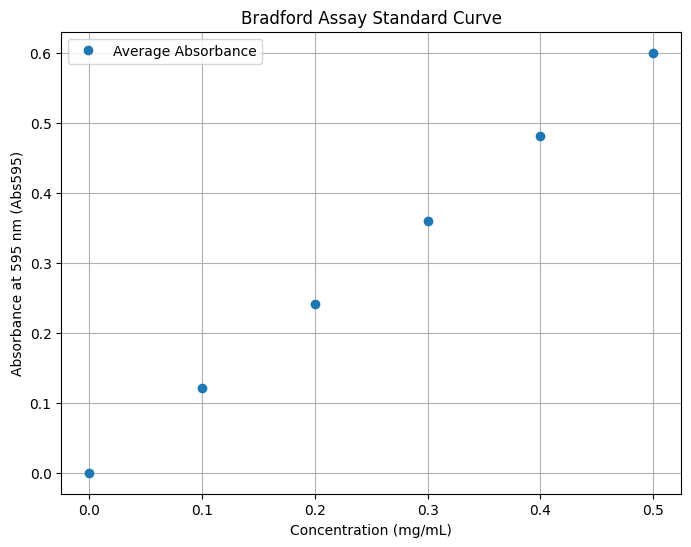

In [12]:
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(clean_data_df['Concentration_mg_per_mL'], clean_data_df['average'], 'o', label='Average Absorbance')

# Add labels and title
plt.xlabel('Concentration (mg/mL)')
plt.ylabel('Absorbance at 595 nm (Abs595)')
plt.title('Bradford Assay Standard Curve')
plt.grid(True)
plt.legend()
plt.show()

4.3 Add error bars

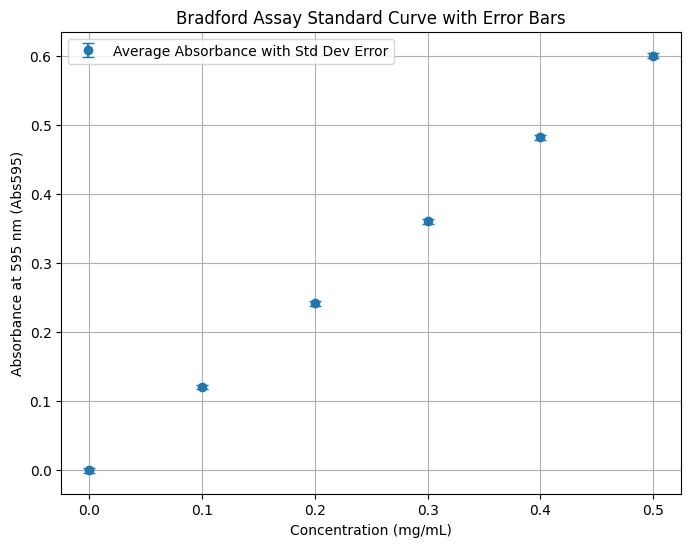

In [13]:
# 4.3 Add error bars to the plot

# Create the plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(
    clean_data_df['Concentration_mg_per_mL'],
    clean_data_df['average'],
    yerr=clean_data_df['standard deviation'],
    fmt='o', # format as circles (no lines)
    capsize=4, # cap size for the error bars
    label='Average Absorbance with Std Dev Error'
)

# Add labels and title
plt.xlabel('Concentration (mg/mL)')
plt.ylabel('Absorbance at 595 nm (Abs595)')
plt.title('Bradford Assay Standard Curve with Error Bars')
plt.grid(True)
plt.legend()
plt.show()

4.3 Determine the best-fit line with R2 and equation added

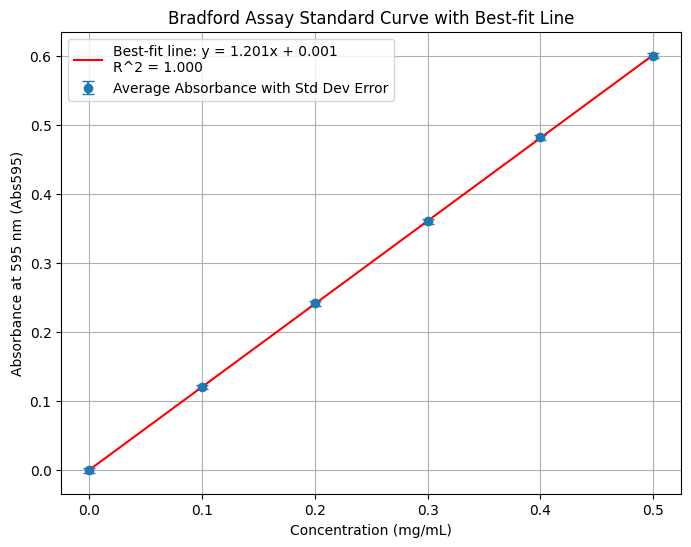

In [15]:
# 4.3 Determine the best-fit line, R-squared, and equation

# Perform linear regression
concentration = clean_data_df['Concentration_mg_per_mL']
average_absorbance = clean_data_df['average']

slope, intercept, r_value, p_value, std_err = stats.linregress(concentration, average_absorbance)

# Calculate R-squared
r_squared = r_value**2

# Generate points for the best-fit line
line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

# Create the plot with error bars and the best-fit line
plt.figure(figsize=(8, 6))
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['standard deviation'],
    fmt='o', # format as circles (no lines)
    capsize=4, # cap size for the error bars
    label='Average Absorbance with Std Dev Error'
)

# Add the best-fit line
plt.plot(line_x, line_y, color='red', label=f'Best-fit line: y = {slope:.3f}x + {intercept:.3f}\nR^2 = {r_squared:.3f}')

# Add labels and title
plt.xlabel('Concentration (mg/mL)')
plt.ylabel('Absorbance at 595 nm (Abs595)')
plt.title('Bradford Assay Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.show()

4.4 Calculate protein concentration for unknowns

We begin with the equation for our standard curve

$$
A_{595} = slope * ProtConc + intercept
$$

which we can rearrange to solve for protein concentration.

$$
ProtConc = \frac{A_{595} - intercept}{slope}
$$

Our final equation will then solve for concentration in mg/mL, based on the units for the slope (/mg/mL) and the unitless intercept.

Now let's put our unknown sample data in a pandas dataframe, write out the code for the equation and use some neat tricks from pandas to add the concentrations to our table.

In [ ]:
protein_conc = ((samples_df[] - intercept) / slope)
print(protein_conc)

# 5. Results & Interpretation

Summarize the findings. Does the result align with the initial assumptions? [cite: 118, 119]

#6. Wrap up text

#OPTIONAL n+1 Challenge questions

Code challenges which are logical extensions of the task or work with alternative data to have students apply their skills.

## Notebook Sign-Off Checklist [cite: 176]

* [ ] **Purpose is clear** from the header without opening code cells. [cite: 177]
* [ ] **Every significant decision** has a markdown explanation. [cite: 178]
* [ ] **Data source and extraction date** are recorded in the header. [cite: 179]
* [ ] **Assumptions and exclusions** are explicitly stated. [cite: 180]
* [ ] **Variable names** indicate both the content and workflow stage. [cite: 146]
* [ ] **Kernel restarted** and all cells run top-to-bottom without error. [cite: 183]